-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


INIZIO PROGETTO


IMPORTA TUTTI GLI STRUMENTI DI LAVORO

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

import os

import math

import requests

import io

CARICA IL DATABASE AGGIORNATO DAL DISCO E MOSTRA LE PRIME RIGHE

In [2]:
df = pd.read_csv("data/SerieA_Aggiornato_2000_2026.csv")

# Mostrare le prime 5 righe
print("Prime 5 righe del dataset")
display(df.head())

# Mostrare le informazioni fondamentali
# print("\nInformazioni sulle colonne")
# df.info()

Prime 5 righe del dataset


,Home Team,Away Team,Home Team Goals Scored,Away Team Goals Scored,Home Team On Target Shots,Away Team On Target Shots,Home Team Corners,Away Team Corners,Home Team Total Shots,Away Team Total Shots,Stagione,Home Team Off Target Shots,Away Team Off Target Shots,Home Team Possession %,Away Team Possession %,Home_ELO,Away_ELO,Differenza_ELO
0,Bari,Verona,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2000/2001,0.0,0.0,50.0,50.0,1500.0,1500.0,0.0
1,Napoli,Juventus,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2000/2001,0.0,0.0,50.0,50.0,1500.0,1500.0,0.0
2,Atalanta,Lazio,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2000/2001,0.0,0.0,50.0,50.0,1500.0,1500.0,0.0
3,Milan,Vicenza,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000/2001,0.0,0.0,50.0,50.0,1500.0,1500.0,0.0
4,Parma,Fiorentina,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2000/2001,0.0,0.0,50.0,50.0,1500.0,1500.0,0.0


PULIZIA DEI DATI, ELIMINANDO LA RIGA FANTASMA '0' E GLI SPAZI NEI NOMI DELLE COLONNE

In [3]:
# Rimuoviamo gli spazi vuoti accidentali all'inizio o alla fine dei nomi delle colonne
df.columns = df.columns.str.strip()

# Eliminiamo le righe "fantasma" o vuote dove il nome della squadra è 0
df = df[(df['Home Team'] != 0) & (df['Home Team'] != '0')]
df = df.reset_index(drop=True)

# Stampiamo la lista esatta delle colonne
print("Lista esatta delle colonne pulite:")
print(df.columns.tolist())

Lista esatta delle colonne pulite:
['Home Team', 'Away Team', 'Home Team Goals Scored', 'Away Team Goals Scored', 'Home Team On Target Shots', 'Away Team On Target Shots', 'Home Team Corners', 'Away Team Corners', 'Home Team Total Shots', 'Away Team Total Shots', 'Stagione', 'Home Team Off Target Shots', 'Away Team Off Target Shots', 'Home Team Possession %', 'Away Team Possession %', 'Home_ELO', 'Away_ELO', 'Differenza_ELO']


CREA L'OBIETTIVO, CALCOLA GLI xG E GENERA LE STATISTICHE SULLO STATO DI FORMA RECENTE DELLE SQUADRE

In [4]:
# STEP 1 : creazione del TARGET
# impostato a PAREGGIO di default
df['Target'] = 0

# se i gol in casa superano quelli in trasferta allora VITTORIA CASA
df.loc[df['Home Team Goals Scored'] > df['Away Team Goals Scored'], 'Target'] = 1

# se i gol in trasferta superano quelli in casa allora VITTORIA TRASFERTA
df.loc[df['Home Team Goals Scored'] < df['Away Team Goals Scored'], 'Target'] = 2

df['Home Team xG'] = (df['Home Team On Target Shots'] * 0.25) + (df['Home Team Off Target Shots'] * 0.05)
df['Away Team xG'] = (df['Away Team On Target Shots'] * 0.25) + (df['Away Team Off Target Shots'] * 0.05)

# STEP 2 : Calcolo STATO DI FORMA
def calcola_statistiche_recenti(df, nome_squadra, indice_corrente, n_partite = 3):
    # si considerano tutte le righe prima di quella corrente
    partite_passate = df.iloc[:indice_corrente]

    # si filtrano solo le partite in cui ha giocato la nostra squadra (casa o trasferta)
    partite_squadra = partite_passate[(partite_passate['Home Team'] == nome_squadra)
                                      | (partite_passate['Away Team'] == nome_squadra)
                                      ].tail(n_partite)
    
    if len(partite_squadra) < n_partite:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    
    gol_fatti = 0
    gol_subiti = 0
    tiri_fatti = 0
    tiri_subiti = 0
    possesso = 0
    angoli_a_favore = 0
    angoli_contro = 0
    xg_squadra = 0

    # si sommano i gol
    for idx, row in partite_squadra.iterrows():
        if row['Home Team'] == nome_squadra:
            gol_fatti += row['Home Team Goals Scored']
            gol_subiti += row['Away Team Goals Scored']
            tiri_fatti += row['Home Team On Target Shots']
            tiri_subiti += row['Away Team On Target Shots']
            possesso += row['Home Team Possession %']
            angoli_a_favore += row['Home Team Corners']
            angoli_contro += row['Away Team Corners']
            xg_squadra += row['Home Team xG']
        else:
            gol_fatti += row['Away Team Goals Scored']
            gol_subiti += row['Home Team Goals Scored']
            tiri_fatti += row['Away Team On Target Shots']
            tiri_subiti += row['Home Team On Target Shots']
            possesso += row['Away Team Possession %']
            angoli_a_favore += row['Away Team Corners']
            angoli_contro += row['Home Team Corners']
            xg_squadra += row['Away Team xG']

    return (gol_fatti / n_partite , gol_subiti / n_partite,
            tiri_fatti / n_partite, tiri_subiti / n_partite,
            possesso / n_partite,
            angoli_a_favore / n_partite, angoli_contro / n_partite,
            xg_squadra / n_partite)

colonne_statistiche = [
'Home_Form_Gol_Fatti','Home_Form_Gol_Subiti','Away_Form_Gol_Fatti','Away_Form_Gol_Subiti',
'Home_Form_Tiri_Fatti','Home_Form_Tiri_Subiti','Away_Form_Tiri_Fatti','Away_Form_Tiri_Subiti',
'Home_Form_Possesso','Away_Form_Possesso',
'Home_Form_Angoli_Fatti','Home_Form_Angoli_Subiti','Away_Form_Angoli_Fatti','Away_Form_Angoli_Subiti',
'Home_Form_xG', 'Away_Form_xG']

for col in colonne_statistiche:
    df[col] = 0.0

for idx, row in df.iterrows():
    # Calcolo per la squadra in casa
    (hf_gf, hf_gs, hf_tf, hf_ts, hf_p, hf_af, hf_as, hf_xg) = calcola_statistiche_recenti(df, row['Home Team'], idx)
    df.at[idx, 'Home_Form_Gol_Fatti'] = hf_gf
    df.at[idx, 'Home_Form_Gol_Subiti'] = hf_gs
    df.at[idx, 'Home_Form_Tiri_Fatti'] = hf_tf
    df.at[idx, 'Home_Form_Tiri_Subiti'] = hf_ts
    df.at[idx, 'Home_Form_Possesso'] = hf_p
    df.at[idx, 'Home_Form_Angoli_Fatti'] = hf_af
    df.at[idx, 'Home_Form_Angoli_Subiti'] = hf_as
    df.at[idx, 'Home_Form_xG'] = hf_xg
    
    # Calcolo per la squadra in trasferta
    (af_gf, af_gs, af_tf, af_ts, af_p, af_af, af_as, af_xg) = calcola_statistiche_recenti(df, row['Away Team'], idx)
    df.at[idx, 'Away_Form_Gol_Fatti'] = af_gf
    df.at[idx, 'Away_Form_Gol_Subiti'] = af_gs
    df.at[idx, 'Away_Form_Tiri_Fatti'] = af_tf
    df.at[idx, 'Away_Form_Tiri_Subiti'] = af_ts
    df.at[idx, 'Away_Form_Possesso'] = af_p
    df.at[idx, 'Away_Form_Angoli_Fatti'] = af_af
    df.at[idx, 'Away_Form_Angoli_Subiti'] = af_as
    df.at[idx, 'Away_Form_xG'] = af_xg

print("Calcolo terminato!")


Calcolo terminato!


1. La Scelta del Modello

DIVIDE I DATI, ADDESTRA UN MODELLO BASE VELOCE E CALCOLA LA PRIMA ACCURATEZZA

In [5]:
# Si definiscono X --> le variabili da studiare e y --> il target
X = df[colonne_statistiche]
y = df['Target']

# SPLIT (80% Train, 20% Test)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Partite usate per imparare (Train): {len(X_train)}")
print(f"Partite usate per l'esame (Test): {len(X_test)}")

# CREAZIONE ED ADDESTRAMENTO DEL MODELLO
modello = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modello.fit(X_train, y_train)

# Previsioni 
y_pred = modello.predict(X_test)

# Valutazione
accuratezza = accuracy_score(y_test, y_pred)
print(f"L'accuratezza del modello base è: {accuratezza * 100: .2f}%")

# Confronto delle prime 10 previsioni con la realtà
confronto = pd.DataFrame({
    'Partita': df.iloc[split_index:split_index+10]['Home Team'] + ' vs '
    + df.iloc[split_index:split_index+10]['Away Team'],
    'Previsione del modello': y_pred[:10],
    'Risultato Reale': y_test[:10].values
})
display(confronto)

Partite usate per imparare (Train): 7513
Partite usate per l'esame (Test): 1879
L'accuratezza del modello base è:  45.08%


,Partita,Previsione del modello,Risultato Reale
7513,Napoli vs Juventus,1,1
7514,Atalanta vs Fiorentina,2,2
7515,Sampdoria vs Inter,2,0
7516,Cagliari vs Genoa,1,2
7517,Spezia vs Udinese,1,2
7518,Torino vs Salernitana,1,1
7519,Milan vs Lazio,1,1
7520,Roma vs Sassuolo,1,1
7521,Bologna vs Verona,1,1
7522,Sassuolo vs Torino,1,2


CREA IL GRAFICO A BARRE PER VEDERE QUALI STATISTICHE SONO PIU' IMPORTANTI PER IL MODELLO

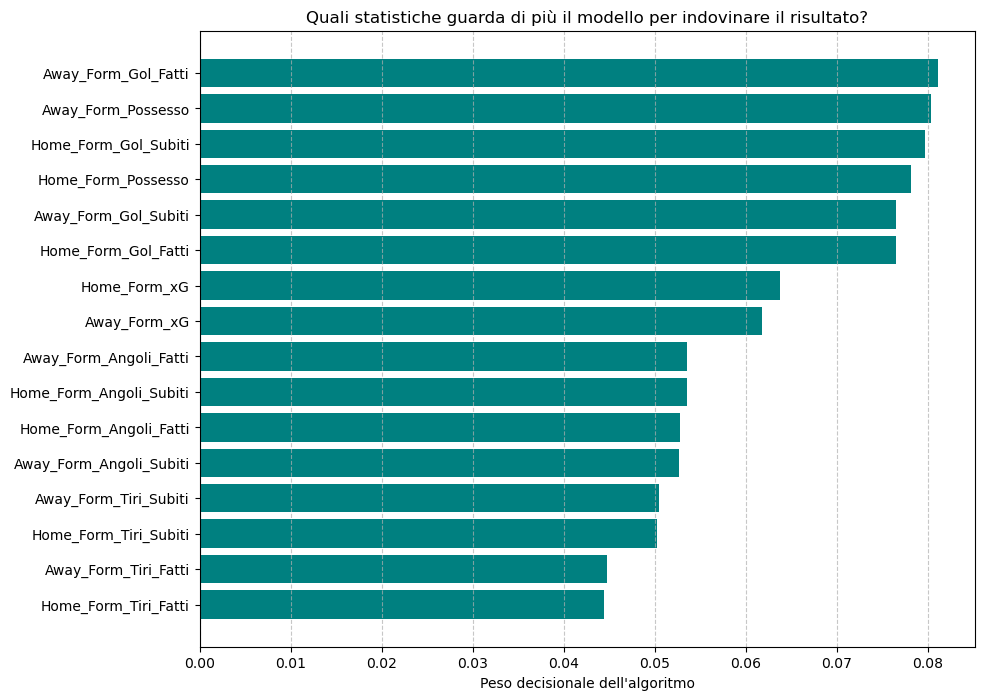

In [6]:
# si estrae l'importanza delle feature direttamente dal modello
importanza = modello.feature_importances_

# creazione della tabella per la visualizzazione
df_importanza = pd.DataFrame({
    'Statistica': colonne_statistiche,
    'Importanza': importanza
})

# ordinamento dalla meno importante alla più importante
df_importanza = df_importanza.sort_values(by='Importanza', ascending=True)

# grafico
plt.figure(figsize=(10, 8))
plt.barh(df_importanza['Statistica'], df_importanza['Importanza'], color='teal')
plt.xlabel('Peso decisionale dell\'algoritmo')
plt.title('Quali statistiche guarda di più il modello per indovinare il risultato?')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

CREA LA 'MATRICE DI CONFUSIONE' PER VEDERE QUANTI PAREGGI O VITTORIE SONO STATE AZZECATI O SBAGLIATI

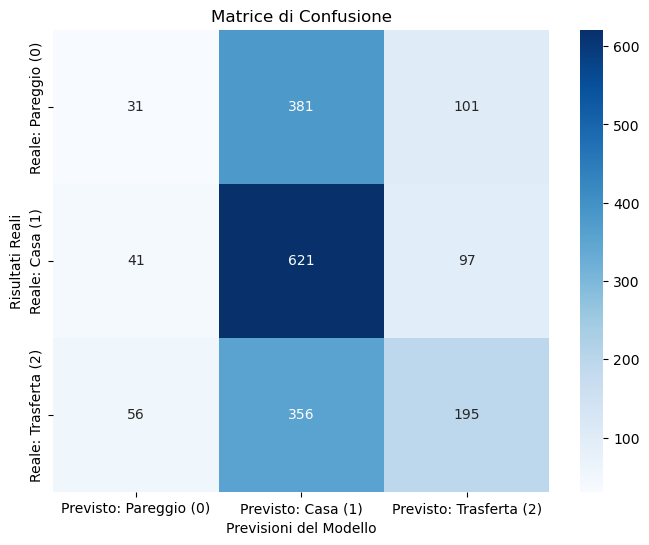

In [7]:
# Calcolo della matrice di confusione
matrice_confusione = confusion_matrix(y_test, y_pred)

# Creazione della HEATMAP
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_confusione, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: Pareggio (0)', 'Previsto: Casa (1)', 'Previsto: Trasferta (2)'],
            yticklabels=['Reale: Pareggio (0)', 'Reale: Casa (1)', 'Reale: Trasferta (2)'])

plt.title('Matrice di Confusione')
plt.xlabel('Previsioni del Modello')
plt.ylabel('Risultati Reali')
plt.show()

CALCOLA LO STORICO DEI 'TESTA A TESTA' ED AGGIUNGE LE COLONNE

In [8]:
# Calcolo dei TESTA A TESTA
def calcola_h2h(df, squadra_casa, squadra_trasferta, indice_corrente, n_scontri = 5):
    # si considera tutto il passato
    storico = df.iloc[:indice_corrente]

    # si filtrano SOLO le partite dove queste squadre si sono incontrate
    scontri_diretti = storico[
        ((storico['Home Team'] == squadra_casa) & (storico['Away Team'] == squadra_trasferta)) 
        | ((storico['Home Team'] == squadra_trasferta) & (storico['Away Team'] == squadra_casa)) 
    ].tail(n_scontri)

    vittorie_casa_h2h = 0
    vittorie_trasferta_h2h = 0
    pareggi_h2h = 0

    if len(scontri_diretti) == 0:
        return 0.0, 0.0, 0.0
    
    for idx, row in scontri_diretti.iterrows():
        # si allineano i risultati storici a chi gioca in casa oggi
        if row['Home Team'] == squadra_casa:
            if row['Target'] == 1: vittorie_casa_h2h += 1
            elif row['Target'] == 2: vittorie_trasferta_h2h += 1
            else: pareggi_h2h += 1
        else:
            # la squadra che gioca oggi in casa, nello scontro storico era in trasferta
            if row['Target'] == 2: vittorie_casa_h2h += 1
            elif row['Target'] == 1: vittorie_trasferta_h2h += 1
            else: pareggi_h2h += 1
    
    totale = len(scontri_diretti)

    return vittorie_casa_h2h / totale, vittorie_trasferta_h2h / totale,  pareggi_h2h / totale

df['H2H_Vittorie_Casa'] = 0.0
df['H2H_Pareggi'] = 0.0
df['H2H_Vittorie_Trasferta'] = 0.0

for idx, row in df.iterrows():
    v_casa, pareggi, v_trasf = calcola_h2h(df, row['Home Team'], row['Away Team'], idx)
    df.at[idx, 'H2H_Vittorie_Casa'] = v_casa
    df.at[idx, 'H2H_Pareggi'] = pareggi
    df.at[idx, 'H2H_Vittorie_Trasferta'] = v_trasf

print("Testa a Testa calcolati!")
display(df[['Home Team', 'Away Team', 'H2H_Vittorie_Casa', 'H2H_Pareggi', 'H2H_Vittorie_Trasferta']].tail(5))

Testa a Testa calcolati!


,Home Team,Away Team,H2H_Vittorie_Casa,H2H_Pareggi,H2H_Vittorie_Trasferta
9387,Cremonese,Como,0.0,0.0,1.0
9388,Lecce,Genoa,0.2,0.4,0.4
9389,Milan,Cagliari,0.6,0.0,0.4
9390,Torino,Juventus,0.0,0.4,0.6
9391,Verona,Roma,0.4,0.6,0.0


USA LE COORDINATE GEOGRAFICHE PER CALCOLARE I CHILOMETRI PERCORSI DALLA SQUADRA IN TRASFERTA

In [9]:
# calcolo della distanza percorsa dalla squadra in trasferta

# 1. Dizionario geografico: Latitudine e Longitudine delle città di Serie A
coordinate_citta = {
    'Juventus': (45.0703, 7.6868), 'Torino': (45.0703, 7.6868),          # Torino
    'Milan': (45.4642, 9.1900),  'Inter': (45.4642, 9.1900),             # Milano
    'Roma': (41.9028, 12.4964), 'Lazio': (41.9028, 12.4964),             # Roma
    'Napoli': (40.8518, 14.2681),                                        # Napoli
    'Atalanta': (45.6983, 9.6773),                                       # Bergamo
    'Fiorentina': (43.7696, 11.2558),                                    # Firenze
    'Bologna': (44.4949, 11.3426),                                       # Bologna
    'Sassuolo': (44.5434, 10.9135),                                      # Reggio Emilia
    'Verona': (45.4384, 10.9916), 'Chievo': (45.4384, 10.9916),          # Verona
    'Genoa': (44.4056, 8.9463), 'Sampdoria': (44.4056, 8.9463),          # Genova
    'Lecce': (40.3515, 18.1750),                                         # Lecce
    'Salernitana': (40.6824, 14.7681),                                   # Salerno
    'Udinese': (46.0619, 13.2378),                                       # Udine
    'Cagliari': (39.2238, 9.1116),                                       # Cagliari
    'Empoli': (43.7181, 10.9453),                                        # Empoli
    'Frosinone': (41.6398, 13.3414),                                     # Frosinone
    'Spezia': (44.1025, 9.8241),                                         # La Spezia
    'Venezia': (45.4408, 12.3155),                                       # Venezia
    'Cremonese': (45.1332, 10.0256),                                     # Cremona
    'Parma': (44.8015, 10.3279),                                         # Parma
    'Brescia': (45.5416, 10.2168),                                       # Brescia
    'Spal': (44.8381, 11.6198),                                          # Ferrara
    'Benevento': (41.1329, 14.7735),                                     # Benevento
    'Crotone': (39.0808, 17.1276),                                       # Crotone
    'Cesena': (44.1391, 12.2432),                                        # Cesena
    'Carpi': (44.7833, 10.8833),                                         # Carpi
    'Pescara': (42.4618, 14.2161),                                       # Pescara
    'Palermo': (38.1157, 13.3615),                                       # Palermo
    'Livorno': (43.5485, 10.3106),                                       # Livorno
    'Ancona': (43.6158, 13.5186),                                        # Ancona
    'Monza': (45.5845, 9.2735),                                          # Monza
    'Novara': (45.4469, 8.6212),                                         # Novara
    'Reggina': (38.1066, 15.6375),                                       # Reggina
    'Perugia': (43.1107, 12.3908),                                       # Perugia
    'Vicenza': (45.5455, 11.5354),                                       # Vicenza
    'Messina': (38.1938, 15.5540),                                       # Messina
    'Modena': (44.6471, 10.9252),                                        # Modena
    'Piacenza': (45.0526, 9.6929),                                       # Piacenza
    'Siena': (43.3188, 11.3308),                                         # Siena
    'Como': (45.8081, 9.0852),                                           # Como
    'Catania': (37.5079, 15.0830),                                       # Catania
    'Ascoli': (42.8532, 13.5757),                                        # Ascoli
    'Pisa': (43.7228, 10.4017),                                          # Pisa
    'Treviso': (45.6669, 12.2461),                                       # Treviso
    'Bari': (41.1171, 16.8719)                                           # Bari
}

# 2. Funzione matematica per calcolare la distanza in KM sulla sfera terrestre
def calcola_distanza_km(lat1, lon1, lat2, lon2):
    R = 6371.0 # Raggio della Terra in km
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# 3. Creiamo la nuova feature nel dataset
df['Fatica_Trasferta_km'] = 0.0

squadre_non_trovate = set()

for idx, row in df.iterrows():
    sq_casa = row['Home Team'].strip()
    sq_trasferta = row['Away Team'].strip()
    
    # Verifichiamo di avere le coordinate di entrambe
    if sq_casa in coordinate_citta and sq_trasferta in coordinate_citta:
        coord_casa = coordinate_citta[sq_casa]
        coord_trasferta = coordinate_citta[sq_trasferta]
        
        # Calcoliamo i KM che la squadra in trasferta ha dovuto viaggiare per arrivare allo stadio
        distanza = calcola_distanza_km(coord_casa[0], coord_casa[1], coord_trasferta[0], coord_trasferta[1])
        df.at[idx, 'Fatica_Trasferta_km'] = distanza
    else:
        # Se manca qualche squadra nel dizionario, la salviamo per aggiungerla
        if sq_casa not in coordinate_citta: squadre_non_trovate.add(sq_casa)
        if sq_trasferta not in coordinate_citta: squadre_non_trovate.add(sq_trasferta)

if squadre_non_trovate:
    print(f"🚨 ATTENZIONE! Manca la città per queste squadre: {squadre_non_trovate}")
    print("Aggiungile al dizionario 'coordinate_citta' per non avere chilometri a zero!")
else:
    print("✅ Calcolo completato con successo per tutte le partite!")

✅ Calcolo completato con successo per tutte le partite!


PRENDE TUTTE LE COLONNE CREATE, AVVIA LA RICERCA DELLA CONFIGURAZIONE PERFETTA E ADDESTRA IL MODELLO OTTIMIZZATO

In [10]:
# Aggiungiamo le nuove colonne dei TESTA A TESTA alla lista di feature
colonne_finali = colonne_statistiche + ['H2H_Vittorie_Casa', 'H2H_Pareggi', 'H2H_Vittorie_Trasferta', 
                                        'Fatica_Trasferta_km', 'Differenza_ELO']

X = df[colonne_finali]
y = df['Target']

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]


# 1. Definiamo la "griglia" delle manopole da provare
griglia_parametri = {
    'n_estimators': [100, 200, 300, 500],           # Quanti alberi usare
    'max_depth': [None, 5, 10, 15, 20],             # Quanto scendere nel dettaglio
    'min_samples_split': [2, 5, 10, 20],            # Regola per dividere i dati
    'min_samples_leaf': [1, 2, 5, 10],              # Foglie minime finali
    'max_features': ['sqrt', 'log2', None]          # Quante statistiche guardare contemporaneamente
}

# 2. Creiamo il modello base vuoto
modello_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 3. Impostiamo il ricercatore automatico
# n_iter=20 significa che proverà 20 combinazioni diverse casuali
# cv=3 significa che farà il test incrociato (Cross-Validation) per evitare di farsi ingannare dalla fortuna
# n_jobs=-1 dice al Mac di usare tutta la potenza del suo processore
ricerca = RandomizedSearchCV(estimator=modello_base, param_distributions=griglia_parametri, 
                             n_iter=20, cv=3, verbose=1, random_state=42, n_jobs=-1)

# 4. Facciamo partire l'allenamento intensivo!
ricerca.fit(X_train, y_train)

print("\n✅ Tuning completato!")
print("I parametri perfetti trovati dall'IA sono:")
print(ricerca.best_params_)

# 5. Estraiamo il modello CAMPIONE (quello con la configurazione migliore)
modello_definitivo = ricerca.best_estimator_

# 6. Mettiamolo alla prova sull'esame finale (Test set)
previsioni_finali = modello_definitivo.predict(X_test)
accuratezza_finale = accuracy_score(y_test, previsioni_finali)

print(f"\n🚀 L'accuratezza del MODELLO OTTIMIZZATO è: {accuratezza_finale * 100:.2f}%")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Tuning completato!
I parametri perfetti trovati dall'IA sono:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

🚀 L'accuratezza del MODELLO OTTIMIZZATO è: 50.93%


SALVATAGGIO DEL PRIMO MODELLO OTTIMIZZATO LOCALMENTE

In [11]:
# Creiamo una cartella 'modelli' se non esiste già
os.makedirs('modelli', exist_ok=True)

# 1. Salviamo il modello addestrato
percorso_modello = 'modelli/random_forest_calcio.pkl'
joblib.dump(modello_definitivo, percorso_modello)

# 2. Salviamo anche la lista delle colonne, così in futuro sapremo esattamente 
# quali dati dare in pasto al modello per fare una previsione
percorso_colonne = 'modelli/colonne_modello.pkl'
joblib.dump(colonne_finali, percorso_colonne)

print(f"Modello salvato con successo in: {percorso_modello}")

Modello salvato con successo in: modelli/random_forest_calcio.pkl


CREAZIONE DEL NUOVO MODELLO PER GLI OVER/UNDER E SALVATAGGIO LOCALMENTE

In [12]:
print("⚽ Addestramento del Secondo Modello per gli Over/Under 2.5...")

colonna_gol_casa = 'Home Team Goals Scored'
colonna_gol_trasferta = 'Away Team Goals Scored'


# 2. Creiamo il target: 1 se la partita finisce in OVER (> 2.5 gol), 0 se finisce in UNDER
df['Totale_Gol'] = df[colonna_gol_casa] + df[colonna_gol_trasferta]
y_ou = (df['Totale_Gol'] > 2.5).astype(int)

# 3. Creiamo e addestriamo il nuovo modello 
# Usiamo la stessa X (statistiche storiche ed ELO) già pulite
modello_ou = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
modello_ou.fit(X, y_ou)

# 4. Salviamo il modello
joblib.dump(modello_ou, 'modelli/modello_over_under.pkl')

print("✅ Secondo modello (Over/Under) addestrato e salvato con successo!")

⚽ Addestramento del Secondo Modello per gli Over/Under 2.5...
✅ Secondo modello (Over/Under) addestrato e salvato con successo!


----------------------------------------------------------------------------------

2. PREDIZIONE PARTITE FUTURE

CELLA DI TEST PER STAMPARE I NOMI DELLE SQUADRE

In [13]:
# lista esatta delle squadre nel dataset
print(df['Home Team'].unique())

['Bari' 'Napoli' 'Atalanta' 'Milan' 'Parma' 'Perugia' 'Reggina' 'Roma'
 'Udinese' 'Inter' 'Lazio' 'Bologna' 'Brescia' 'Fiorentina' 'Juventus'
 'Lecce' 'Verona' 'Vicenza' 'Chievo' 'Piacenza' 'Torino' 'Venezia' 'Como'
 'Modena' 'Empoli' 'Ancona' 'Sampdoria' 'Siena' 'Cagliari' 'Palermo'
 'Livorno' 'Messina' 'Ascoli' 'Treviso' 'Catania' 'Genoa' 'Cesena'
 'Novara' 'Pescara' 'Sassuolo' 'Frosinone' 'Carpi' 'Crotone' 'Benevento'
 'Spal' 'Spezia' 'Salernitana' 'Monza' 'Cremonese' 'Pisa']


SI CONNETTE AD API-FOOTBALL E SCARICA LA LISTA UFFICIALE DEGLI INFORTUNATI

In [14]:
# INSERISCI LA TUA CHIAVE API QUI SOTTO
API_KEY = "e41ac0cad3b1dc1fe101a1a8e7792f06" 
HEADERS = {"x-apisports-key": API_KEY}

def ottieni_infortunati_live(nome_squadra):
    try:
        # Formattiamo il nome per l'API (es. da "JUVENTUS" a "Juventus")
        squadra_formattata = nome_squadra.capitalize()
        if squadra_formattata == "Milan" or squadra_formattata == "Ac milan":
            squadra_formattata = "AC Milan"
        elif squadra_formattata == "Inter":
            squadra_formattata = "Inter"
            
        # 1. Troviamo l'ID della squadra
        res_team = requests.get("https://v3.football.api-sports.io/teams", 
                                headers=HEADERS, params={"name": squadra_formattata, "country": "Italy"})
        
        dati_team = res_team.json()
        if not dati_team.get('response'): 
            return [] # Squadra non trovata
        team_id = dati_team['response'][0]['team']['id']
        
        # 2. Troviamo la PROSSIMA partita in calendario
        res_fixture = requests.get("https://v3.football.api-sports.io/fixtures", 
                                   headers=HEADERS, params={"team": team_id, "next": "1"})
        
        dati_fixture = res_fixture.json()
        if not dati_fixture.get('response'): 
            return [] # Nessuna partita in programma
        fixture_id = dati_fixture['response'][0]['fixture']['id']
        
        # 3. Scarichiamo l'elenco ufficiale degli infortunati / squalificati
        res_injuries = requests.get("https://v3.football.api-sports.io/injuries", 
                                    headers=HEADERS, params={"fixture": fixture_id})
        
        infortunati = []
        for inj in res_injuries.json().get('response', []):
            # Filtriamo solo i giocatori della nostra squadra
            if inj['team']['id'] == team_id:
                nome_giocatore = inj['player']['name']
                motivo = inj['player'].get('reason', 'Indisponibile')
                infortunati.append(f"{nome_giocatore} ({motivo})")
                
        return infortunati
        
    except Exception as e:
        print(f"⚠️ Errore nel recupero dati live per {nome_squadra}: {e}")
        return []

VERIFICA CHI E' L'ARBITRO DESIGNATO PER LA PARTITA TRAMITE API-FOOTBALL

In [15]:
def ottieni_arbitro_live(nome_squadra):
    try:
        squadra_formattata = nome_squadra.capitalize()
        
        # 🧠 IL NOSTRO TRADUTTORE DI NOMI PER L'API
        dizionario_nomi = {
            "Milan": "AC Milan",
            "Ac milan": "AC Milan",
            "Inter": "Inter",
            "Verona": "Hellas Verona",
            "Roma": "Roma",
            "Spal": "SPAL"
            # Se in futuro vedi di nuovo "Sconosciuto", ti basta aggiungere 
            # il nome esatto qui dentro!
        }
        
        # Se la squadra è nel dizionario, usa il nome tradotto, altrimenti usa l'originale
        if squadra_formattata in dizionario_nomi:
            squadra_formattata = dizionario_nomi[squadra_formattata]
            
        res_team = requests.get("https://v3.football.api-sports.io/teams", 
                                headers=HEADERS, params={"name": squadra_formattata, "country": "Italy"}).json()
        
        if not res_team.get('response'): 
            return f"Sconosciuto (Nome '{squadra_formattata}' non trovato)"
            
        team_id = res_team['response'][0]['team']['id']
        
        res_fixture = requests.get("https://v3.football.api-sports.io/fixtures", 
                                   headers=HEADERS, params={"team": team_id, "next": "1"}).json()
        
        if not res_fixture.get('response'): 
            return "Nessun match imminente"
        
        arbitro = res_fixture['response'][0]['fixture']['referee']
        return arbitro if arbitro else "Da designare"
        
    except Exception as e:
        return "Errore connessione"

CONTROLLA IL METEO ATTRAVERSO OPEN-METEO ED LONGITUDINE, LATITUDINE IMPOSTATI SOPRA

In [16]:
def ottieni_meteo_stadio(squadra_casa):
    # WMO Weather codes: 0=Sereno, 1-3=Nuvoloso, 51-67=Pioggia, 71-77=Neve, 95-99=Tempesta
    if squadra_casa in coordinate_citta:
        lat, lon = coordinate_citta[squadra_casa]
        url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
        
        try:
            res = requests.get(url).json()
            codice_meteo = res['current_weather']['weathercode']
            temperatura = res['current_weather']['temperature']
            
            if 51 <= codice_meteo <= 67:
                return f"Pioggia 🌧️ ({temperatura}°C)", 0.85 # -15% xG per campo pesante
            elif 71 <= codice_meteo <= 77:
                return f"Neve ❄️ ({temperatura}°C)", 0.70 # -30% xG per campo ghiacciato
            elif codice_meteo >= 95:
                return f"Tempesta ⛈️ ({temperatura}°C)", 0.80 # -20% xG 
            else:
                return f"Sereno/Nuvoloso 🌤️ ({temperatura}°C)", 1.0 # Condizioni ottimali, nessun malus
        except:
            return "Dati non disponibili ❓", 1.0
    return "Stadio non trovato ❓", 1.0

# Test Veloce!
print("Sensori Attivati!")

Sensori Attivati!


UNISCE IL CALCOLO DELLA FORMA, I CHILOMETRI, L'ARBITRO, IL METEO E GLI INFORTUNATI IN TEMPO REALE E STAMPA IL REFERTO CON L'ESITO

In [17]:
def predici_partita_live(squadra_casa, squadra_trasferta):
    print("⏳ Caricamento statistiche e collegamento ai server (Infortuni, Meteo, Arbitro)...")
    
    indice_attuale = len(df)
    
    # 1. Calcolo Statistiche Storiche e H2H
    (hf_gf, hf_gs, hf_tf, hf_ts, hf_p, hf_af, hf_as, hf_xg) = calcola_statistiche_recenti(df, squadra_casa, indice_attuale)
    (af_gf, af_gs, af_tf, af_ts, af_p, af_af, af_as, af_xg) = calcola_statistiche_recenti(df, squadra_trasferta, indice_attuale)
    v_casa_h2h, v_trasf_h2h, pareggi_h2h = calcola_h2h(df, squadra_casa, squadra_trasferta, indice_attuale)
    
    # 2. Calcolo Fatica da Trasferta
    km_trasferta = 0.0
    if squadra_casa in coordinate_citta and squadra_trasferta in coordinate_citta:
        coord_c = coordinate_citta[squadra_casa]
        coord_t = coordinate_citta[squadra_trasferta]
        km_trasferta = calcola_distanza_km(coord_c[0], coord_c[1], coord_t[0], coord_t[1])

    # 3. Calcolo ELO Attuale
    try:
        elo_casa_attuale = df[df['Home Team'] == squadra_casa]['Home_ELO'].iloc[-1]
        elo_trasf_attuale = df[df['Away Team'] == squadra_trasferta]['Away_ELO'].iloc[-1]
        differenza_elo = elo_casa_attuale - elo_trasf_attuale
    except IndexError:
        differenza_elo = 0.0

    # =========================================================
    # 🌟 CONNESSIONE API MULTIPLA: INFORTUNI, METEO E ARBITRO
    # =========================================================
    assenze_casa = ottieni_infortunati_live(squadra_casa)
    assenze_trasferta = ottieni_infortunati_live(squadra_trasferta)
    arbitro = ottieni_arbitro_live(squadra_casa)
    meteo_descrizione, malus_meteo = ottieni_meteo_stadio(squadra_casa)
    
    # Applichiamo i Malus INFORTUNI
    if len(assenze_casa) > 0:
        hf_xg *= max(1.0 - (0.05 * len(assenze_casa)), 0.5) 
        hf_p *= max(1.0 - (0.01 * len(assenze_casa)), 0.8)

    if len(assenze_trasferta) > 0:
        af_xg *= max(1.0 - (0.05 * len(assenze_trasferta)), 0.5)
        af_p *= max(1.0 - (0.01 * len(assenze_trasferta)), 0.8)

    # Applichiamo il Malus METEO (Campo pesante riduce gli xG di entrambe)
    hf_xg *= malus_meteo
    af_xg *= malus_meteo

    # 4. Creazione del pacchetto dati
    dati_partita = {
        'Home_Form_Gol_Fatti': [hf_gf], 'Home_Form_Gol_Subiti': [hf_gs],
        'Away_Form_Gol_Fatti': [af_gf], 'Away_Form_Gol_Subiti': [af_gs],
        'Home_Form_Tiri_Fatti': [hf_tf], 'Home_Form_Tiri_Subiti': [hf_ts],
        'Away_Form_Tiri_Fatti': [af_tf], 'Away_Form_Tiri_Subiti': [af_ts],
        'Home_Form_Possesso': [hf_p], 'Away_Form_Possesso': [af_p],
        'Home_Form_Angoli_Fatti': [hf_af], 'Home_Form_Angoli_Subiti': [hf_as],
        'Away_Form_Angoli_Fatti': [af_af], 'Away_Form_Angoli_Subiti': [af_as],
        'H2H_Vittorie_Casa': [v_casa_h2h], 
        'H2H_Pareggi': [v_trasf_h2h], 
        'H2H_Vittorie_Trasferta': [pareggi_h2h],
        'Fatica_Trasferta_km': [km_trasferta],
        'Home_Form_xG': [hf_xg], 'Away_Form_xG': [af_xg],
        'Differenza_ELO': [differenza_elo]
    }
    
    df_live = pd.DataFrame(dati_partita, columns=colonne_finali) 
        
    print("\n" + "="*55)
    print(f"🔥 REPORT MATCH: {squadra_casa} vs {squadra_trasferta} 🔥")
    print("="*55)
    print(f"⚖️ Bilancio ELO: {differenza_elo:.1f} punti di differenza")
    print(f"✈️ Fatica in viaggio per {squadra_trasferta}: {km_trasferta:.0f} km")
    
    print("\n🌍 CONDIZIONI AMBIENTALI E ARBITRALI:")
    print(f"   🌤️ Meteo sullo stadio: {meteo_descrizione}")
    if malus_meteo < 1.0:
        print("      (⚠️ Allerta campo pesante: Statistiche xG ridotte automaticamente!)")
    print(f"   👮‍♂️ Arbitro designato:  {arbitro}")
    
    print("\n🚑 BOLLETTINO MEDICO UFFICIALE:")
    if assenze_casa:
        print(f"   ❌ {squadra_casa} ({len(assenze_casa)} assenti):")
        for nome in assenze_casa: print(f"      - {nome}")
    else:
        print(f"   ✅ {squadra_casa}: Rosa al completo!")
        
    if assenze_trasferta:
        print(f"   ❌ {squadra_trasferta} ({len(assenze_trasferta)} assenti):")
        for nome in assenze_trasferta: print(f"      - {nome}")
    else:
        print(f"   ✅ {squadra_trasferta}: Rosa al completo!")

    print(f"\n📈 CONDIZIONE (Post-Malus Infortuni & Meteo):")
    print(f"   🏠 {squadra_casa} -> xG Potenziale: {hf_xg:.1f} | Possesso: {hf_p:.1f}%")
    print(f"   ✈️ {squadra_trasferta} -> xG Potenziale: {af_xg:.1f} | Possesso: {af_p:.1f}%")
    
    # 5. Previsione 
    # --- Cervello 1: Risultato Esatto ---
    previsione_1X2 = modello_definitivo.predict(df_live)[0]
    probabilita_1X2 = modello_definitivo.predict_proba(df_live)[0]
    risultato_testo_1X2 = {0: "Pareggio (X)", 1: "Vittoria Casa (1)", 2: "Vittoria Trasferta (2)"}
    
    # --- Cervello 2: Over/Under 2.5 ---
    modello_ou = joblib.load('modelli/modello_over_under.pkl')
    previsione_ou = modello_ou.predict(df_live)[0]
    probabilita_ou = modello_ou.predict_proba(df_live)[0]
    risultato_testo_ou = {0: "UNDER 2.5 (Massimo 2 gol)", 1: "OVER 2.5 (3 o più gol)"}
    
    # 🖨️ STAMPA DEL DOPPIO REPORT

   
    print(f"\n🤖 MODELLO 1 (ESITO FINALE): {risultato_testo_1X2[previsione_1X2]}")
    
    print(f"1 (Vittoria {squadra_casa}): {probabilita_1X2[1] * 100:.1f}%")
    print(f"X (Pareggio): {probabilita_1X2[0] * 100:.1f}%")
    print(f"2 (Vittoria {squadra_trasferta}): {probabilita_1X2[2] * 100:.1f}%")
    
 
    print(f"\n⚽ MODELLO 2 (GOL TOTALI): {risultato_testo_ou[previsione_ou]}")

    print(f"UNDER 2.5: {probabilita_ou[0] * 100:.1f}%")
    print(f"OVER 2.5:  {probabilita_ou[1] * 100:.1f}%")

In [18]:
predici_partita_live('Verona', 'Roma')

⏳ Caricamento statistiche e collegamento ai server (Infortuni, Meteo, Arbitro)...

🔥 REPORT MATCH: Verona vs Roma 🔥
⚖️ Bilancio ELO: -280.6 punti di differenza
✈️ Fatica in viaggio per Roma: 411 km

🌍 CONDIZIONI AMBIENTALI E ARBITRALI:
   🌤️ Meteo sullo stadio: Sereno/Nuvoloso 🌤️ (24.3°C)
   👮‍♂️ Arbitro designato:  Nessun match imminente

🚑 BOLLETTINO MEDICO UFFICIALE:
   ✅ Verona: Rosa al completo!
   ✅ Roma: Rosa al completo!

📈 CONDIZIONE (Post-Malus Infortuni & Meteo):
   🏠 Verona -> xG Potenziale: 1.3 | Possesso: 41.6%
   ✈️ Roma -> xG Potenziale: 2.2 | Possesso: 66.9%

🤖 MODELLO 1 (ESITO FINALE): Vittoria Trasferta (2)
1 (Vittoria Verona): 6.8%
X (Pareggio): 17.2%
2 (Vittoria Roma): 76.0%

⚽ MODELLO 2 (GOL TOTALI): OVER 2.5 (3 o più gol)
UNDER 2.5: 46.6%
OVER 2.5:  53.4%


3. GENERAZIONE ELO (da eseguire ogni volta che si modifica il dataset)

In [19]:
#print("🧠 Inizializzazione Sistema ELO interno...")

# 1. Carichiamo il dataset aggiornato
#df = pd.read_csv('data/SerieA_Aggiornato_2000_2026.csv')

# 2. Tutte le squadre partono da 1500 punti ELO
#elo_squadre = {squadra: 1500.0 for squadra in df['Home Team'].unique()}

#def calcola_probabilita_elo(elo_a, elo_b):
#    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

#def aggiorna_elo(elo_a, elo_b, risultato_a, k=20):
#    prob_a = calcola_probabilita_elo(elo_a, elo_b)
#    nuovo_elo_a = elo_a + k * (risultato_a - prob_a)
#    nuovo_elo_b = elo_b + k * ((1 - risultato_a) - (1 - prob_a))
#    return nuovo_elo_a, nuovo_elo_b

#home_elo_list = []
#away_elo_list = []

#VANTAGGIO_CASA = 50 # Giocare in casa vale virtualmente 50 punti ELO in più

# 3. Simuliamo lo scorrere del tempo dal 2000 a oggi
#for index, row in df.iterrows():
#    casa = row['Home Team']
#    trasferta = row['Away Team']
    
    # Registriamo l'ELO *prima* che la partita venga giocata
#    elo_attuale_casa = elo_squadre[casa]
#    elo_attuale_trasferta = elo_squadre[trasferta]
    
#    home_elo_list.append(elo_attuale_casa)
#    away_elo_list.append(elo_attuale_trasferta)
    
    # Vediamo chi ha vinto
#    gol_casa = row['Home Team Goals Scored']
#    gol_trasf = row['Away Team Goals Scored']
    
#    if gol_casa > gol_trasf:
#        risultato = 1.0 # Vittoria
#    elif gol_casa < gol_trasf:
#        risultato = 0.0 # Sconfitta
#    else:
#        risultato = 0.5 # Pareggio
        
    # Calcoliamo i nuovi punteggi post-partita
#    nuovo_casa, nuovo_trasf = aggiorna_elo(elo_attuale_casa + VANTAGGIO_CASA, elo_attuale_trasferta, risultato)
    
    # Salviamo i nuovi punteggi per la prossima giornata (rimuovendo il bonus casa temporaneo)
#    elo_squadre[casa] = nuovo_casa - VANTAGGIO_CASA
#    elo_squadre[trasferta] = nuovo_trasf

# 4. Inseriamo i dati nel DataFrame
#df['Home_ELO'] = home_elo_list
#df['Away_ELO'] = away_elo_list

# LA STATISTICA D'ORO: Chi è più forte in questo esatto momento storico?
#df['Differenza_ELO'] = df['Home_ELO'] - df['Away_ELO']

# Salviamo e sovrascriviamo
#df.to_csv('data/SerieA_Aggiornato_2000_2026.csv', index=False)

#print("✅ Punteggi storici ELO calcolati e salvati con successo!")
#print("\n🏆 CLASSIFICA ELO ATTUALE (Le 5 squadre più forti oggi):")
#classifica_attuale = pd.Series(elo_squadre).sort_values(ascending=False)
#print(classifica_attuale.head(5))

RICERCA DELLE ' VALUE BET ' CONFRONTO CON I BOOKMAKERS

In [20]:
def cerca_value_bet(prob_ai_1, prob_ai_X, prob_ai_2, quota_book_1, quota_book_X, quota_book_2):
    print("📊 ANALISI VALUE BET 📊")
    print("="*40)
    
    esiti = ["1 (Casa)", "X (Pareggio)", "2 (Trasferta)"]
    prob_ai = [prob_ai_1, prob_ai_X, prob_ai_2]
    quote_book = [quota_book_1, quota_book_X, quota_book_2]
    
    trovata_value_bet = False
    
    for i in range(3):
        # Calcoliamo la probabilità implicita del bookmaker
        prob_bookmaker = 100 / quote_book[i]
        
        # Calcoliamo quale dovrebbe essere la quota "Giusta" (Fair Odds) secondo la tua IA
        quota_reale_ai = 100 / prob_ai[i]
        
        print(f"\nEsito {esiti[i]}:")
        print(f"  - Quota Bookmaker: {quote_book[i]:.2f} (Prob: {prob_bookmaker:.1f}%)")
        print(f"  - Quota del tuo modello:    {quota_reale_ai:.2f} (Prob: {prob_ai[i]:.1f}%)")
        
        # Se la nostra probabilità è maggiore di quella del bookmaker... C'È VALORE!
        if prob_ai[i] > prob_bookmaker:
            vantaggio = prob_ai[i] - prob_bookmaker
            print(f"  🔥 VALUE BET TROVATA! Vantaggio matematico: +{vantaggio:.1f}%")
            trovata_value_bet = True
        else:
            print("  ❌ Nessun valore. Lascia perdere questa quota.")
            
    print("\n" + "="*40)
    if not trovata_value_bet:
        print("Conclusione: Il Bookmaker ha prezzato perfettamente la partita. Nessuna scommessa consigliata.")
    else:
        print("Conclusione: Trovato potenziale errore del bookmaker! Valuta la scommessa segnalata con 🔥.")


# Sostituisci i primi tre numeri con le percentuali della tua IA (senza il simbolo %)
# Sostituisci i secondi tre numeri con le quote reali che trovi su Snai/Bet365 oggi
cerca_value_bet(6.8, 17.2, 76.0,   7.20, 3.45, 1.38)

📊 ANALISI VALUE BET 📊

Esito 1 (Casa):
  - Quota Bookmaker: 7.20 (Prob: 13.9%)
  - Quota del tuo modello:    14.71 (Prob: 6.8%)
  ❌ Nessun valore. Lascia perdere questa quota.

Esito X (Pareggio):
  - Quota Bookmaker: 3.45 (Prob: 29.0%)
  - Quota del tuo modello:    5.81 (Prob: 17.2%)
  ❌ Nessun valore. Lascia perdere questa quota.

Esito 2 (Trasferta):
  - Quota Bookmaker: 1.38 (Prob: 72.5%)
  - Quota del tuo modello:    1.32 (Prob: 76.0%)
  🔥 VALUE BET TROVATA! Vantaggio matematico: +3.5%

Conclusione: Trovato potenziale errore del bookmaker! Valuta la scommessa segnalata con 🔥.


DOWNLOAD DEL FILE DELLE QUOTE

In [21]:
print("🧬 Avvio operazione Data Merge (FUSIONE DATASET)...")

url_quote = "https://www.football-data.co.uk/mmz4281/2324/I1.csv"

# 1. La Maschera Perfetta: Inseriamo gli header esatti di un browser reale
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/csv,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8'
}

try:
    risposta = requests.get(url_quote, headers=headers, timeout=10)
    risposta.raise_for_status() # Controlla che la risposta sia "200 OK"
    
    df_quote = pd.read_csv(io.StringIO(risposta.text))
    print("✅ File quote storiche scaricato con successo dal server internazionale!")
    
    # Abbiamo inserito tutto il resto del codice QUI DENTRO. 
    # Verrà eseguito SOLO se il download va a buon fine!
    
    df_quote_light = df_quote[['Date', 'HomeTeam', 'AwayTeam', 'B365H', 'B365D', 'B365A']].copy()

    traduzione_squadre_eng_it = {
        'AC Milan': 'Milan', 'Inter': 'Inter', 'Juventus': 'Juventus', 'Roma': 'Roma',
        'Lazio': 'Lazio', 'Fiorentina': 'Fiorentina', 'Atalanta': 'Atalanta', 'Napoli': 'Napoli',
        'Torino': 'Torino', 'Bologna': 'Bologna', 'Monza': 'Monza', 'Genoa': 'Genoa',
        'Lecce': 'Lecce', 'Frosinone': 'Frosinone', 'Udines': 'Udinese', 'Udinese': 'Udinese',
        'Empoli': 'Empoli', 'Verona': 'Verona', 'Cagliari': 'Cagliari', 'Sassuolo': 'Sassuolo',
        'Salernitana': 'Salernitana'
    }

    df_quote_light['HomeTeam'] = df_quote_light['HomeTeam'].map(traduzione_squadre_eng_it).fillna(df_quote_light['HomeTeam'])
    df_quote_light['AwayTeam'] = df_quote_light['AwayTeam'].map(traduzione_squadre_eng_it).fillna(df_quote_light['AwayTeam'])

    df_super = pd.merge(df, df_quote_light, left_on=['Home Team', 'Away Team'], right_on=['HomeTeam', 'AwayTeam'], how='left')
    df_super = df_super.drop(columns=['HomeTeam', 'AwayTeam', 'Date'])

    # Aggiorniamo il dataset principale
    df = df_super

    print("🧬 FUSIONE COMPLETATA!")
    print(f"Ora il tuo dataset ha {df.shape[1]} colonne. Ultime 3 righe:")
    display(df[['Home Team', 'Away Team', 'B365H', 'B365D', 'B365A']].tail(3))
    
except Exception as e:
    print(f"❌ Errore critico di connessione: {e}")
    print("💡 Purtroppo il tuo operatore internet o un firewall stanno bloccando Python in modo aggressivo.")

🧬 Avvio operazione Data Merge (FUSIONE DATASET)...
✅ File quote storiche scaricato con successo dal server internazionale!
🧬 FUSIONE COMPLETATA!
Ora il tuo dataset ha 45 colonne. Ultime 3 righe:


,Home Team,Away Team,B365H,B365D,B365A
9389,Milan,Cagliari,1.40,5.25,6.50
9390,Torino,Juventus,3.75,3.00,2.20
9391,Verona,Roma,4.33,3.50,1.83


MACCHINA DEL TEMPO

Come leggere i risultati:

•	Se il grafico è un disastro rosso che va verso lo zero, significa che il modello è bravo a indovinare chi vince, ma si fa "fregare" dai bookmaker sulle quote (sovra-stima le favorite che hanno quote troppo basse per ripagare le sconfitte fisiologiche).

•	Se il grafico è un trend verde che sale costantemente, hai letteralmente costruito una macchina da soldi matematica. Significa che il tuo ROI (Ritorno sull'Investimento) è positivo.

🎯 Avvio Macchina del Tempo (Versione Cecchino - Filtri Attivati)...
📊 Simulazione su 1879 partite storiche. Analisi quote in corso...

💰 REPORT FINANZIARIO CECCHINO 💰
Scommesse Piazzate (solo Value Bet ultra-filtrate): 234
Vinte: 98 | Perse: 136 (Win Rate: 41.9%)
ROI (Ritorno sull'Investimento): 4.54%
Cassa Finale: 206.30€ (Profitto Netto: +106.30€)


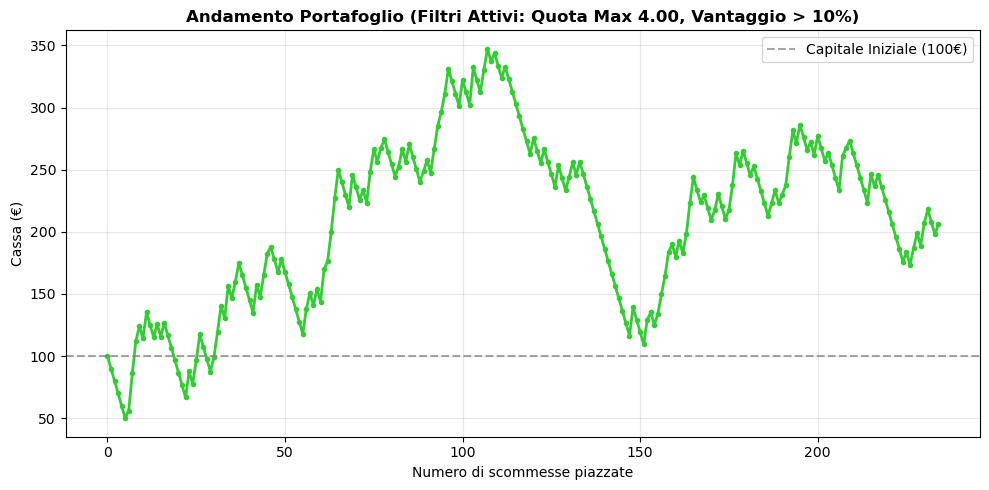

In [ ]:
print("🎯 Avvio Macchina del Tempo (Versione Cecchino - Filtri Attivati)...")

# Si sceglono solo le partite dell'ultimo anno per valutare le possibili partite su cui puntare
PARTITE_ULTIMO_ANNO = 380

# Isiliamo il "Test Set" (Le partite future su cui il modello si è messo alla prova)
df_storico = df.tail(PARTITE_ULTIMO_ANNO).copy()
X_storico = X.tail(PARTITE_ULTIMO_ANNO).copy()
y_storico = y.tail(PARTITE_ULTIMO_ANNO).copy()

# Impostazioni Finanziarie
CASSA_INIZIALE = 100.0   
PUNTATA = 10.0           

cassa_attuale = CASSA_INIZIALE
andamento_cassa = [cassa_attuale]
scommesse_vinte = 0
scommesse_perse = 0

previsioni = modello_definitivo.predict(X_storico)
probabilita = modello_definitivo.predict_proba(X_storico)

idx_pareggio = list(modello_definitivo.classes_).index(0)
idx_casa = list(modello_definitivo.classes_).index(1)
idx_trasferta = list(modello_definitivo.classes_).index(2)

print(f"📊 Simulazione su {len(df_storico)} partite storiche. Analisi quote in corso...")

for i in range(len(df_storico)):
    risultato_reale = y_storico.iloc[i]
    quota_1 = df_storico.iloc[i]['B365H']
    quota_X = df_storico.iloc[i]['B365D']
    quota_2 = df_storico.iloc[i]['B365A']
    
    if np.isnan(quota_1) or np.isnan(quota_X) or np.isnan(quota_2):
        continue
        
    prob_ai_1 = probabilita[i][idx_casa]
    prob_ai_X = probabilita[i][idx_pareggio]
    prob_ai_2 = probabilita[i][idx_trasferta]
    
    prob_book_1 = 1 / quota_1
    prob_book_X = 1 / quota_X
    prob_book_2 = 1 / quota_2
    

    # I NUOVI FILTRI 
 
    SOGLIA_VANTAGGIO = 0.10  # Aumentata dal 5% al 10%
    QUOTA_MINIMA = 1.50      # Niente scommesse con guadagno ridicolo
    QUOTA_MASSIMA = 4.00     # Niente quote impossibili
   
    
    scommessa_effettuata = False
    quota_giocata = 0
    esito_giocato = -1
    
    # Valutiamo il segno 1 (Casa)
    if (prob_ai_1 - prob_book_1) > SOGLIA_VANTAGGIO and (QUOTA_MINIMA <= quota_1 <= QUOTA_MASSIMA):
        scommessa_effettuata = True
        quota_giocata = quota_1
        esito_giocato = 1
        
    # Valutiamo il segno 2 (Trasferta)
    elif (prob_ai_2 - prob_book_2) > SOGLIA_VANTAGGIO and (QUOTA_MINIMA <= quota_2 <= QUOTA_MASSIMA):
        scommessa_effettuata = True
        quota_giocata = quota_2
        esito_giocato = 2
        
    if scommessa_effettuata:
        cassa_attuale -= PUNTATA
        
        if esito_giocato == risultato_reale:
            vincita = PUNTATA * quota_giocata
            cassa_attuale += vincita
            scommesse_vinte += 1
        else:
            scommesse_perse += 1
            
        andamento_cassa.append(cassa_attuale)

# Resoconto
totale_scommesse = scommesse_vinte + scommesse_perse
win_rate = (scommesse_vinte / totale_scommesse * 100) if totale_scommesse > 0 else 0
profitto = cassa_attuale - CASSA_INIZIALE
roi = (profitto / (totale_scommesse * PUNTATA) * 100) if totale_scommesse > 0 else 0

print("\n" + "="*40)
print("💰 REPORT FINANZIARIO CECCHINO 💰")
print("="*40)
print(f"Scommesse Piazzate (solo Value Bet ultra-filtrate): {totale_scommesse}")
print(f"Vinte: {scommesse_vinte} | Perse: {scommesse_perse} (Win Rate: {win_rate:.1f}%)")
print(f"ROI (Ritorno sull'Investimento): {roi:.2f}%")
print(f"Cassa Finale: {cassa_attuale:.2f}€ (Profitto Netto: {profitto:+.2f}€)")
print("="*40)

# Grafico
plt.figure(figsize=(10, 5))
colore_linea = 'limegreen' if profitto >= 0 else 'red'
plt.plot(andamento_cassa, color=colore_linea, linewidth=2, marker='o', markersize=3)
plt.axhline(y=CASSA_INIZIALE, color='gray', linestyle='--', alpha=0.7, label='Capitale Iniziale (100€)')
plt.title('Andamento Portafoglio (Filtri Attivi: Quota Max 4.00, Vantaggio > 10%)', fontsize=12, fontweight='bold')
plt.xlabel('Numero di scommesse piazzate', fontsize=10)
plt.ylabel('Cassa (€)', fontsize=10)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()